In [3]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.8 MB 10.0 MB/s eta 0:00:01
   ------------- -------------------------- 3.4/9.8 MB 10.1 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.8 MB 9.4 MB/s eta 0:00:01
   ------------------------ --------------- 6.0/9.8 MB 8.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 7.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 6.8 MB/s  0:00:01
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.5 MB 5.2 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.5 MB 5.2 MB/s eta 0:00:02
   ---------- --------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Sofía\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [36]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/9.3 MB 12.7 MB/s eta 0:00:01
   ------------------- -------------------- 4.5/9.3 MB 11.0 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 9.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 9.0 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.3 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 3.0 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 3.3 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 3.6 MB/s  0:00:00
   -------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Sofía\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import os

In [ ]:
# reading one month of data (df = dataFrame)
df = pd.read_csv("../data/Sales_Data/Sales_April_2019.csv")
# displaying the data
df.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


Merging 12 months of sales data into a single file

In [ ]:
# listing all files
files = [file for file in os.listdir('../data/Sales_Data')]

# empty data frame
all_months_data = pd.DataFrame() 

for file in files:
    df = pd.read_csv("../data/Sales_Data/"+file)
    all_months_data = pd.concat([all_months_data, df])

# export to csv
all_months_data.to_csv("../data/output/all_data.csv", index=False)

In [62]:
all_data = pd.read_csv("../data/output/all_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


#### Clean out the data

In [63]:
# all_data.head(100)
# drop rows of NaN
nan_df = all_data[all_data.isna().any(axis=1)] # viva stackoverflow
nan_df.head()

# all = only drops if all columns are NaN
all_data = all_data.dropna(how='all')

In [64]:
# there's an 'Or' throught the months
# temp_df = all_data[#condition] <-- index all_data based on a condition
temp_df = all_data[all_data['Order Date'].str[0:2] == 'Or']
temp_df.head()
# result: titles of the rows duplicated

all_data = all_data[all_data['Order Date'].str[0:2] != 'Or']
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


#### Convert columns to correct type

In [74]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])
# to_numeric is same as astype but type is authomatic

## QUESTION 1: What was the best month for sales? How much was earned that month?

#### 1.1. Augment data with additional columns

##### 1.1.1. Month Column

In [ ]:
# english date display: month is in the first two characters of the date
# new columns is just all_data['new column']
all_data['Month'] = all_data['Order Date'].str[0:2]
all_data['Month'] = all_data['Month'].astype('int32') # str to int
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4


##### 1.1.2. Sales Column (Quantity Ordereed * Price Each)

In [30]:
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']
all_data.head()
# you can rearange columns


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


### 1.2. Solution

In [49]:
all_data.groupby('Month').sum()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales
Month,,,,,,,
1,2971502978172978172979692983442990492991253003...,Lightning Charging CableiPhoneLightning Chargi...,10903,1811768.38,01/01/20 00:3801/01/20 00:2201/01/20 00:2201/0...,"427 Wilson St, Dallas, TX 75001519 13th St, Ne...",1822256.73
2,1505021505031505041505051505061505071505081505...,iPhoneAA Batteries (4-pack)27in 4K Gaming Moni...,13449,2188884.72,02/18/19 01:3502/13/19 07:2402/18/19 09:4602/0...,"866 Spruce St, Portland, ME 0410118 13th St, S...",2202022.42
3,1505331505411508121517491520361532841535441538...,AAA Batteries (4-pack)AAA Batteries (4-pack)Wi...,17005,2791207.83,03/01/19 03:0603/01/19 01:0303/01/19 02:1803/0...,"270 Dogwood St, San Francisco, CA 94016683 Ada...",2807100.38
4,1765581765591765601765601765611765621765631765...,USB-C Charging CableBose SoundSport Headphones...,20558,3367671.02,04/19/19 08:4604/07/19 22:3004/12/19 14:3804/1...,"917 1st St, Dallas, TX 75001682 Chestnut St, B...",3390670.24
5,1769781775511777781777781790761790761791341800...,Apple Airpods Headphones27in FHD MonitoriPhone...,18667,3135125.13,05/01/19 03:2905/01/19 00:1305/01/19 00:4805/0...,"589 Lake St, Portland, OR 97035615 Lincoln St,...",3152606.75
6,2099212099222099232099242099252099262099272099...,USB-C Charging CableMacbook Pro LaptopThinkPad...,15253,2562025.61,06/23/19 19:3406/30/19 10:0506/24/19 20:1806/0...,"950 Walnut St, Portland, ME 0410180 4th St, Sa...",2577802.26
7,2229102229112229122229132229142229152229162229...,Apple Airpods HeadphonesFlatscreen TVAA Batter...,16072,2632539.56,07/26/19 16:5107/05/19 08:5507/29/19 12:4107/2...,"389 South St, Atlanta, GA 30301590 4th St, Sea...",2647775.76
8,2366702366712366722366732366742366752366762366...,Wired HeadphonesBose SoundSport HeadphonesiPho...,13448,2230345.42,08/31/19 22:2108/15/19 15:1108/06/19 14:4008/2...,"359 Spruce St, Seattle, WA 98101492 Ridge St, ...",2244467.88
9,2388342392852406362410542423432428652436672449...,Apple Airpods Headphones34in Ultrawide Monitor...,13109,2084992.09,09/01/19 04:1309/01/19 01:0909/01/19 02:0709/0...,"761 Forest St, San Francisco, CA 94016373 1st ...",2097560.13


In [54]:
# this command creates a series, not a table!!
# results_sales = all_data.groupby('Month').sum()['Sales']

results = pd.DataFrame()
# results = results.assign(Month=pd.Series(range(1,13)))
results = results.assign(Sales=results_sales)
results.head(13)


,Sales
Month,
1,1822256.73
2,2202022.42
3,2807100.38
4,3390670.24
5,3152606.75
6,2577802.26
7,2647775.76
8,2244467.88
9,2097560.13


Solution: best month was december with 4613443.34

In [55]:
results.columns

Index(['Sales'], dtype='str')

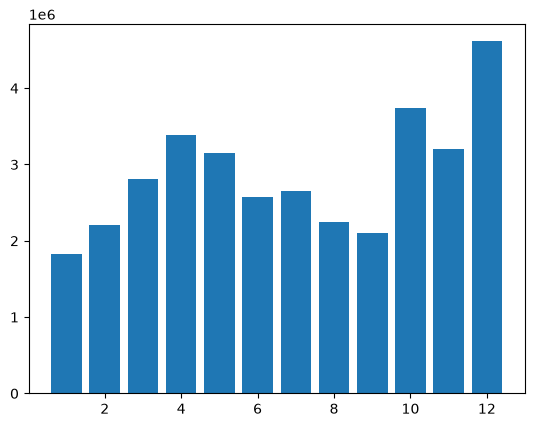

In [56]:
import matplotlib.pyplot as plt

months = range(1,13) # does not reach 13
plt.bar(months, results['Sales'])
plt.show()

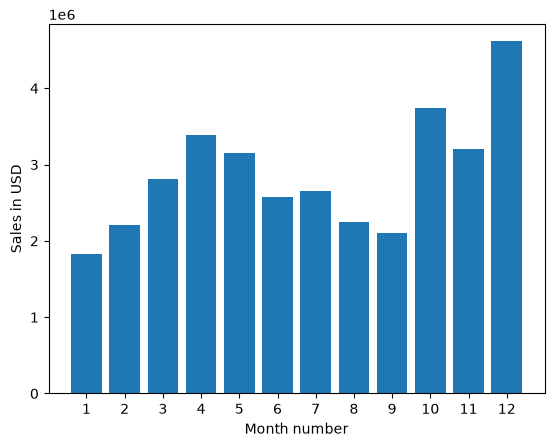

In [58]:
months = range(1,13) # does not reach 13
plt.bar(months, results['Sales'])

plt.xticks(months)
plt.ylabel('Sales in USD')
plt.xlabel('Month number')
plt.show()

### QUESTION 2: What city had the hightest number of sales?

In [59]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",4,23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",4,99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",4,11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",4,11.99


In [ ]:
all_data['City'] = all_data['Purchase Address'].str.split(", ").str[1]
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,City
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",Dallas
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",Boston
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",Los Angeles


In [75]:
result2 = all_data.groupby('City').sum()['Quantity Ordered']
result2.head(100)

City
Atlanta          16602
Austin           11153
Boston           22528
Dallas           16730
Los Angeles      33289
New York City    27932
Portland         14053
San Francisco    50239
Seattle          16553
Name: Quantity Ordered, dtype: int64

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('int64'), dtype('<U1')) -> None